Telco Customer Churn
---

    - Chosen dataset:
A dataset that was released by IBM Sample Data Sets, on the customers of a telecommunications company (Telco). The dataset contains various information on the customers, examples being their gender, payment methods, and many more. Additionally, it provides the information on whether or not the customer discontinued the given service, or in other words churned, within a month.

    - Business problem:
To what extent can Telco predict whether a customer will cancel their service, based on the information given on the customers?

    - Why is it important?:
Marketing uses a lot of resources to acquire more new customers, hence showing that customer acquisition is not only very important but also quite expensive. Whenever a company is on the verge of losing a customer perks, such as bonus discounts, get blindly assigned to everyone. This wastes a lot of money, as some might have not left in the first place or there might be some customers who were going to leave no matter what. 
Instead these resources could be used on customers who actually need this intervention and be the focus of retention efforts. This highlights the importance of identifying the churn of customers, as a company can step in before potentially losing a customer, hence keeping their clientele.

    - Benefits:
Being able to identify the churn rate of customers is very significant, as that way, marketing would know where to delegate its resources more effectively.
On top of that, having these data driven insights would allow the company to better prepare and tackle the issue of customers leaving. Instead of only focusing on separate clients, the company could work on improving the underlying pricing strategy or anything else that could be causing this issue of churn in the first place.

    - How will we know if its beneficial or not?
To test out if it was actually beneficial or not, the company's churn rate before the retention methods that were modified based on the data collected by the model and after. So the database would be constantly updated and the results would be compared. Depending on whether or not these new strategies lead to a decrease in churn rate or not would show if the model ended up being useful. 


    - How is the relevant data being collected?
For this assignment, I am using an already existing dataset provided by IBM. 
In an actual setting, the company would first start by collecting the information regarding the bills. The details of the each customer as well as other features such as the details of the contract, would be collected to replicate the information that is in the dataset that I am utilizing.
Carrying on, the churn status of each client would also automatically be recorded whenever a person cancels the service. This would allow for a passive form of data collection that updates continuously without the need of direct intervention.

    - Formulating this problem as a machine learning task:
This problem uses the idea of a binary classification task.
The dataset is broken down in a way where the information regarding a customer, such as their account details, is separated into rows. The target variable of this problem is Churn, where if a customer left within the last month they are labeled as 'Yes' and if not, then they have the 'No' label. The model learns the relationships between the various charateristics of the customer and the possibility of them discountinuing the service. This way a prediction is created for future new customers. 
Instead of relying on the vague idea of 'customer loyalty', the model focuses on creating a concrete prediction, which can be used later by the company to improve their marketing techniques and flag down customers that are highly likely to churn.

In [709]:
import datetime
import pandas as pd
import numpy as np

start_time = datetime.datetime.now()

df = pd.read_csv('telco.csv')

---
Data Exploration: Overlooking Everything
---

In [710]:
print(df.shape) 
#Shows that there are 7043 rows and 21 columns.

(7043, 21)


In [711]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [712]:
df.describe().T[['mean', 'std', 'min', 'max']].head()

,mean,std,min,max
SeniorCitizen,0.162147,0.368612,0.00,1.00
tenure,32.371149,24.559481,0.00,72.00
MonthlyCharges,64.761692,30.090047,18.25,118.75


In [713]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [714]:
print("Throughout the dataset, there are", df.duplicated().sum(), "duplicate rows.")

Throughout the dataset, there are 0 duplicate rows.


---
Data Exploration: Splitting Data
---

In [715]:
from sklearn.model_selection import train_test_split


train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['Churn']
)
#By adding stratify, the proportion of churned customers in both the training and test sets is maintained.

print('Training set shape:', train_df.shape)
print('Test set shape:', test_df.shape)

Training set shape: (5634, 21)
Test set shape: (1409, 21)


    - Splitting:
To ensure that there is no data leakage and that both training and test data get evaluated by themselves, a random 80/20 split was applied. By adding the stratify argument into the split, it makes sure that both of the sets have the same proportions of churned or not churned customers when compared to the original data set. That way the possibility of one of the sets being randomly skewed is removed as an issue.

---
Data Exploration: Data Types
---

In [716]:
df.dtypes 
#To understand which data types the dataset contains

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [717]:
#TotalCharges is said to be a string, but it should instead be a numerical value.

train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')
#By adding the errors argument, any values that cannot be turned into a numerical value will instead be replaced with NaN.

print(train_df['TotalCharges'].dtype)
print('Missing TotalCharges:', train_df['TotalCharges'].isna().sum())
#Thanks to the coerce argument, we can now see that there were 8 missing values.

float64
Missing TotalCharges: 8


    - Data Types: 
It can be seen that although most of the columns are categorical, there are a few that were numerical. After a careful examnination, it was found out that there was only one column that had a misleading data type: TotalCharges. Despite containing numerical values, it was stored as the string type. After being changed to the numeric type, a few missing values, that were previously undetected as they were hidden as blank strings, were discovered.

---
Data Exploration: Finding Explicit Missing Values
---

In [718]:
train_df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        8
Churn               0
dtype: int64

    - Missing Values:
In the raw data set, no missing values (or NaN) were found except from the ones that was revealed after the conversion of TotalCharges. During a check of implicit missing values, a few tenure values were found to be equal to 0. However, after a closer inspection it was found out that these values were normal and just suggested that the customer was new.

---
Data Exploration: Finding Implicit Missing Values
---

In [719]:
#Checking categorical columns and if they have weird/unknown values

categorical_columns = ['gender','Partner','Dependents','PhoneService','MultipleLines',
            'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
            'TechSupport','StreamingTV','StreamingMovies','Contract',
            'PaperlessBilling','PaymentMethod','Churn']
for col in categorical_columns:
    print(col, ':', train_df[col].unique())

#So it goes through all of the categorical columns and prints out the unique values.

gender : <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Partner : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
TechSupport : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
Contract : <StringArray>
['Month-to-month', 

In [720]:
#A check for hidden, blank or whitespace in columns that have strings.

text_cols = train_df.select_dtypes(include='object').columns
for col in text_cols:
    empty_count = (train_df[col].astype(str).str.strip() == '').sum()
    if empty_count > 0:
        print(col, 'has', empty_count, 'blank values')
    else:
        print(col, 'has no blank values')

customerID has no blank values
gender has no blank values
Partner has no blank values
Dependents has no blank values
PhoneService has no blank values
MultipleLines has no blank values
InternetService has no blank values
OnlineSecurity has no blank values
OnlineBackup has no blank values
DeviceProtection has no blank values
TechSupport has no blank values
StreamingTV has no blank values
StreamingMovies has no blank values
Contract has no blank values
PaperlessBilling has no blank values
PaymentMethod has no blank values
Churn has no blank values


C:\Users\daria\AppData\Local\Temp\ipykernel_29824\3796189624.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = train_df.select_dtypes(include='object').columns


    - Data Quality Issues:
Upon inspecting categorical columns, although all of them were clean, a few of them had redundant information. For example, the column OnlineSecurity has 3 answers, being: "Yes", "No", and "No internet service". The details of internet service are unnecessary as that is already underlined by the "OnlineService" column and does not need to be addressed one more time and could be removed. This is a problem that will need to be fixed during preprocessing. 

In [721]:
#Looks through numerical columns to see if all of the values are valid.

numeric_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

print('Negative tenure:', (train_df['tenure'] < 0).sum())
print('Zero tenure:', (train_df['tenure'] == 0).sum())
print('Negative MonthlyCharges:', (train_df['MonthlyCharges'] < 0).sum())
print('Negative TotalCharges:', (train_df['TotalCharges'] < 0).sum())

Negative tenure: 0
Zero tenure: 8
Negative MonthlyCharges: 0
Negative TotalCharges: 0


    - Missing Values Part 2
After checking the missing values in TotalCharges, it was revealed that they were the same as the ones that were equal to zero in tenure. As these customers are new, they have not been charged yet. Due to this, during preprocessing, the missing values should instead be replaced with zeros in the TotalCharges column.

    - Numerical Checks:
All of the values found in numerical columns were not negative, hence not impossible, meaning that there are no issues there.

---
Data Exploration: Class Balance/Imbalance
---

In [722]:
train_df['Churn'].value_counts()

Churn
No     4139
Yes    1495
Name: count, dtype: int64

Checks the distribution of the Churn columns, which is also the target variable.

The same exact function but in percentages, to be able to visualize the distribution better.
"normalize=True" turns the values in Churn into proportions.

In [723]:
train_df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

    - Balancing of Classes:
As can be seen with the percentages, this dataset suffers from imbalance as 73% of the customers stayed and 27% of them churned. To address this, when calling GridSearch, the dataset will be scored with f1 and thus evaluated. On top of that, to further combat this a class_weight of balanced may be added so that the minority class of churners are penalised.

---

    - Summary of Data Exploration

Throught the data exploration of the Telco Customer dataset, the details about the characteristics revolving around the data came to light. Instead of just looking at the data directly, being able to clearly see information such as data types, distribution of classes and a lot more, will be very useful for the next step involving Data Preprocessing. 

---
Data Preprocessing: Dropping Columns
---

In [724]:
train_df = train_df.drop(columns=['customerID'])
test_df = test_df.drop(columns=['customerID'])


This is a unique identifier that needs to be dropped.

---
Data Preprocessing: Handling Missing Values
---

In [725]:
train_df['TotalCharges'] = train_df['TotalCharges'].fillna(0)
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(0)

train_df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

This is to check if the missing values from TotalCharges were removed or not.
They were properly removed, so we can continue with data preprocessing.

---
Data Preprocessing: Removing Data Redundancy
---

In [726]:
columns_to_simplify = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in columns_to_simplify:
    train_df[col] = train_df[col].replace({'No internet service': 'No', 'No phone service': 'No'})
    test_df[col] = test_df[col].replace({'No internet service': 'No', 'No phone service': 'No'})

for col in columns_to_simplify:
    print(col, ':', train_df[col].unique())

MultipleLines : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineSecurity : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
OnlineBackup : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
DeviceProtection : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
TechSupport : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
StreamingTV : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
StreamingMovies : <StringArray>
['Yes', 'No']
Length: 2, dtype: str


Removes redundancy and also improves data quality by replacing the obvious information.
An example to this, if we already know that a person has no internet service (through the Internet Service column), instead of it saying 'No internet service' in other columns, it just immediately says 'No'.

---
Feature Engineering: Encoding Categorical Columns
---

In [727]:
yes_no = ['Partner', 'Dependents', 'PhoneService', 'MultipleLines',
               'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
               'TechSupport', 'StreamingTV', 'StreamingMovies',
               'PaperlessBilling', 'Churn']

for col in yes_no:
    train_df[col] = train_df[col].map({'Yes': 1, 'No': 0})
    test_df[col] = test_df[col].map({'Yes': 1, 'No': 0})

for col in yes_no:
    print(col, ':', train_df[col].unique())

Partner : [0 1]
Dependents : [0 1]
PhoneService : [0 1]
MultipleLines : [0 1]
OnlineSecurity : [0 1]
OnlineBackup : [0 1]
DeviceProtection : [1 0]
TechSupport : [0 1]
StreamingTV : [1 0]
StreamingMovies : [1 0]
PaperlessBilling : [0 1]
Churn : [0 1]


Takes all of the categorical columns that have yes/no and codes them based on "Yes" as 1 and "No" as 0. This helps when we do Supervised models later on, as scikit models such as Logistic Regression etc. only work with numbers and cannot identify strings. This will also allow us to use the fit function on them.

In [728]:
multiple_categories = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

train_df = pd.get_dummies(train_df, columns=multiple_categories)
test_df = pd.get_dummies(test_df, columns=multiple_categories)

print("Shape of train_df:")
print(train_df.shape)
print("Shape of test_df:")
print(test_df.shape)

Shape of train_df:
(5634, 28)
Shape of test_df:
(1409, 28)


Confirming that get_dummies worked and that the shape of the dataframes. Also confirming that both of the sets have the same amount of columns

    - pandas.get_dummies:
As other feature engineering techniques such as OneHotEncoder would add too much complexity due to changes in fit and transform patterns and many others, instead pandas.get_dummies. Although this was a bit risky, as taught in the lecture, this function may lead to data leakage during supervised learning as there may be a column mismatch. This, however, was not the case as seen by the shape function, both train and test data have the same amount of columns after the encoding process.

---
Feature Engineering: Scaling Numerical Columns
---

In [729]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()

train_df[numeric_cols] = scaler.fit_transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

train_df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,5.634000e+03,5.634000e+03,5.634000e+03
mean,-1.008935e-17,-2.402527e-16,2.522338e-17
std,1.000089e+00,1.000089e+00,1.000089e+00
min,-1.322329e+00,-1.544028e+00,-1.008922e+00
25%,-9.559779e-01,-9.711977e-01,-8.321009e-01
50%,-1.418632e-01,1.848336e-01,-3.968446e-01
75%,9.164859e-01,8.319124e-01,6.741944e-01
max,1.608483e+00,1.785939e+00,2.801869e+00


Takes all of the numerical columns and scales them. This is very important to do as TotalCharges has some very big values. If left alone, these values would drown out tenure. This is prvented by the StandardScaler, which makes it so that each column has a column of 0 and standard deviation of 1. This is then learnt by the training data and applies the transformation, whilst the test data reuses the pattern from training data to prevent data leakage.

---
Quick Time Check
---

In [730]:
end_time = datetime.datetime.now()
print(f"Execution time: {end_time - start_time} seconds")

Execution time: 0:00:00.426085 seconds


---

Model Selection: Supervised Models
---

Before the models are chosen, it is very important to keep a few things in mind. First of all, this is a classification problem as Churn is a category that has Yes/No values rather than a continuous value. On top of that, it is a binary problem, since there are only two possible categories and not more than that. Keeping that in mind, Logistic Regression and K Nearest Neighbours were chosen as the supervised models.

    - Logistic Regression: 
It is able to estimate the probability of a client belonging to a specific class based on the features. The coefficients can be used to make a direct assumptions on which specific features affect Churn the most.

    - KNN: 
It distinguishes a customer based on its K closest neighbours. This creates a good contrast to Logistic Regression, as it has no preemptive assumptions regarding the relationnships between various features and Churn. In turn though, as it does not coefficients like Logistic Regression, you cannot have a deep insight of the features.

---
Model Training: Logistic Regression
---

In [731]:
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']

X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']
#Dropping the target variable from the features.

In [732]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
logistic_regression.fit(X_train, y_train)

y_prediction = logistic_regression.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_prediction))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



Built in predict function uses 50% as a deafult for a threshold to determine whether a customer will churn or not. If necessary, this threshold can be changed, but I decided to keep it the same.

In [733]:
from sklearn.metrics import f1_score, roc_auc_score

y_probability_logistic = logistic_regression.predict_proba(X_test)[:, 1]

print('F1 Score:', f1_score(y_test, y_prediction))
print('ROC-AUC:', roc_auc_score(y_test, y_probability_logistic))

F1 Score: 0.6144200626959248
ROC-AUC: 0.8419075667157508


By ignoring the first column, we are looking only at customers that will churn and not at any of the other features.

In [734]:
logistic_time = datetime.datetime.now()
print(f"Execution time: {logistic_time - start_time} seconds")

Execution time: 0:00:00.502591 seconds


At a later stage, this can be used as a way to compare how long it takes for Logistic Regression and KNN to run.

---
Model Training: K Nearest Neighbours
---

In [735]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_prediction_knn = knn.predict(X_test)

print(classification_report(y_test, y_prediction_knn))

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1035
           1       0.56      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.70      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



It is important to keep in mind that by default there are 5 neighbors used in the KNN model. This is something that can be changed, but is not necessary for now, as this is something that will be played around with in hyperparameter tuning. On top of that, the distance is Euclidean distance.

In [736]:
y_probability_knn = knn.predict_proba(X_test)[:, 1]

print('F1 Score:', f1_score(y_test, y_prediction_knn))    
print('ROC-AUC:', roc_auc_score(y_test, y_probability_knn))

F1 Score: 0.5587044534412956
ROC-AUC: 0.7885414244749284


In [737]:
knn_time = datetime.datetime.now()
print(f"Execution time: {knn_time - start_time} seconds")

logistic_total_time = logistic_time - end_time
knn_total_time = knn_time - logistic_time

print()

print("Execution time for Logistic Regression:", logistic_total_time)
print("Execution time for KNN:", knn_total_time)

Execution time: 0:00:00.584864 seconds

Execution time for Logistic Regression: 0:00:00.076506
Execution time for KNN: 0:00:00.082273


Although the KNN model is faster compared to the Logistic Regression right now, it is impossible to determine which one is better yet as both have yet to be tuned. 

---
Hyperparameter Tuning: Logistic Regression via Grid Search
---

In [738]:
from sklearn.model_selection import GridSearchCV

parameter_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_search_logistic_5 = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    parameter_grid,
    scoring='f1',
    cv=5
)

grid_search_logistic_5.fit(X_train, y_train)

print('Best C:', grid_search_logistic_5.best_params_)
print('Best F1 score (cross-validated):', grid_search_logistic_5.best_score_)

Best C: {'C': 10}
Best F1 score (cross-validated): 0.6332448793208181


- A common trick for the parameters is to use the logarithmic scale

- As seen with the cv value, which is directly correlated to cross validation, the K-Fold Cross Validation technique was used. 5 is a standard value for it.

- For each C value, a different Logistic Regression model is trained, so at the end there are 6 separate models.

In [739]:
grid_search_logistic_diffcv = GridSearchCV(
    LogisticRegression(random_state=42, class_weight='balanced'),
    parameter_grid,
    scoring='f1',
    cv=10
)

grid_search_logistic_diffcv.fit(X_train, y_train)

print('Best C:', grid_search_logistic_diffcv.best_params_)
print('Best F1 score (cross-validated):', grid_search_logistic_diffcv.best_score_)

Best C: {'C': 1}
Best F1 score (cross-validated): 0.6320633339695817


I got curious what would change if I changed the cv value to 10, which is another standar value for it. As the F1 score is quite similar to when cv was 5, I decided to just use cv = 5 moving forward.

In [740]:
logistic_time_tuning = datetime.datetime.now()
logistic_total_time_tuning = logistic_time_tuning - knn_time

print(f"Execution time: {logistic_total_time_tuning} seconds")

Execution time: 0:00:01.665933 seconds


---
Hyperparameter Tuning: K Nearest Neighbours via Grid Search
---

In [741]:
parameter_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

grid_search_knn_5 = GridSearchCV(
    KNeighborsClassifier(),
    parameter_grid_knn,
    scoring='f1',
    cv=5
)

grid_search_knn_5.fit(X_train, y_train)

print('Best n_neighbors:', grid_search_knn_5.best_params_)
print('Best F1 score (cross-validated):', grid_search_knn_5.best_score_)

Best n_neighbors: {'n_neighbors': 15}
Best F1 score (cross-validated): 0.5854733276933303


Odd numbers for neighbors are often used to avoid ties, hence why the parameter grid only contains odd numbers.

In [742]:
parameter_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

grid_search_knn_diffcv = GridSearchCV(
    KNeighborsClassifier(),
    parameter_grid_knn,
    scoring='f1',
    cv=10
)

grid_search_knn_diffcv.fit(X_train, y_train)

print('Best n_neighbors:', grid_search_knn_diffcv.best_params_)
print('Best F1 score (cross-validated):', grid_search_knn_diffcv.best_score_)

Best n_neighbors: {'n_neighbors': 11}
Best F1 score (cross-validated): 0.5818305148019258


Just in case, I wanted to check again if anything would change if the cv was changed to 10. And yet once again, the F1 score was quite similar so cv =5 is still the better option.

In [743]:
knn_time_tuning = datetime.datetime.now()
knn_total_time_tuning = knn_time_tuning - logistic_time_tuning

print(f"Execution time: {knn_total_time_tuning} seconds")

Execution time: 0:00:01.438556 seconds


---
Comparison of Models: Logistic Regression and KNN
---

In [744]:
print('Logistic Regression best F1:', grid_search_logistic_5.best_score_)
print('KNN best F1:', grid_search_knn_5.best_score_)

Logistic Regression best F1: 0.6332448793208181
KNN best F1: 0.5854733276933303


Logistic Regression had a better F1 score than KNN (0.63 > 0.59), so that was chosen as the model moving forward. This also lines up with what was found with the hyperparameter tuning, where Logistic Regression always scored high whilst for KNN heavily depended on the neighbour count to score higher.

In [745]:
print(f"Logistic Regression: {logistic_total_time_tuning + logistic_total_time} seconds")
print(f"KNN: {knn_total_time_tuning + knn_total_time} seconds")

Logistic Regression: 0:00:01.742439 seconds
KNN: 0:00:01.520829 seconds


KNN does take less time to compute everything compared to Logistic Regression, but the difference is negligible. However, if the company is very strict about time limits then it might be worth considering to use KNN, even though the results are definitely not going to be as well computed as Logistic Regression.

---
Model Assessment: Picking the Best Model
---

In [746]:
y_final_prediction = grid_search_logistic_5.predict(X_test)
y_final_probability = grid_search_logistic_5.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_final_prediction))
print('ROC-AUC:', roc_auc_score(y_test, y_final_probability))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8411067193675891


Here the tuned Logistic Regression is applied to a yet unseen test data. The F1 score is 0.61 for Churn and the ROC_AUC of 0.84 shows that this model is good at interpreting which customers have a risk of churning. 

Moving on, a recall of 0.78 is quite high and good, but due to that precision is quite low at 0.51. This is caused by the previously used class weight = balanced. Accuraccy is traded with the model acting more balanced, hence most likely catching customers that won't churn and labelling them as churn. It is, however, more important to catch an at risk customer of churning, so overall the model is quite effective.

In [747]:
y_final_prediction_train = grid_search_logistic_5.predict(X_train)

print('Train F1:', f1_score(y_train, y_final_prediction_train))
print('Test F1:', f1_score(y_test, y_final_prediction))

Train F1: 0.6311647429171039
Test F1: 0.614900314795383


The two data sets have very similar F1 scores, which therefore shows that the tuned Logistic Regression model can generalize quite well to the yet unseen data set. It does not memorize the training data set.

In [768]:
coefficients = pd.Series(
    grid_search_logistic_5.best_estimator_.coef_[0],
    index=X_train.columns
).sort_values(key=abs)

print(coefficients)

Partner                                    0.017900
PaymentMethod_Electronic check            -0.030492
TechSupport                               -0.062287
OnlineBackup                               0.127874
OnlineSecurity                            -0.131444
SeniorCitizen                              0.153281
Dependents                                -0.229139
DeviceProtection                           0.242982
Contract_Month-to-month                    0.302229
PaperlessBilling                           0.332275
PaymentMethod_Mailed check                -0.380241
InternetService_DSL                       -0.403899
Contract_One year                         -0.425790
PaymentMethod_Credit card (automatic)     -0.428197
PaymentMethod_Bank transfer (automatic)   -0.429691
MultipleLines                              0.529055
TotalCharges                               0.534968
gender_Male                               -0.617670
PhoneService                               0.636641
gender_Femal

This shows the coefficients of the model in regards to how strongly they affect churn probability. The higher the value/positive values increase the churn risk, whilst the vice versa decrease it.

---
Model Selection: Unsupervised Model
---

The supervised model focused on predicting whether or not a customer would churn. This section of unsupervised model instead focuses on trying to find customers with similar features into different categories. This allows the model to identify patterns and target different clusters of customers separately, helping the company focus on those instead of treating all clients the same.

    - K Means:
It uses numerical data and focuses on calculating the distance between points. Due to that, it can easily break customers into groups depending on their features. To add on, it is important to note that this section will focus on the columns 'tenure', 'MonthlyCharges' and 'TotalCharges'. Although the main reason for choosing these columns was to evaluate customers' behaviour and value, it is also due to the fact that these columns contain continuous numeric values and are already scaled.

---
Model Selection: K Means
---

In [749]:
X_cluster = train_df[['tenure', 'MonthlyCharges', 'TotalCharges']]
X_cluster_test = test_df[['tenure', 'MonthlyCharges', 'TotalCharges']]

X_cluster.head()

,tenure,MonthlyCharges,TotalCharges
3738,0.102371,-0.521976,-0.262257
3151,-0.711743,0.337478,-0.503635
4860,-0.793155,-0.809013,-0.749883
3867,-0.263980,0.284384,-0.172722
3810,-1.281624,-0.676279,-0.989374


K means is a clustering method and is an unsupervised model. Because of that, it does not need a target variable (which is Churn in this case) to be trained.

---
Model Training: Elbow Method
---

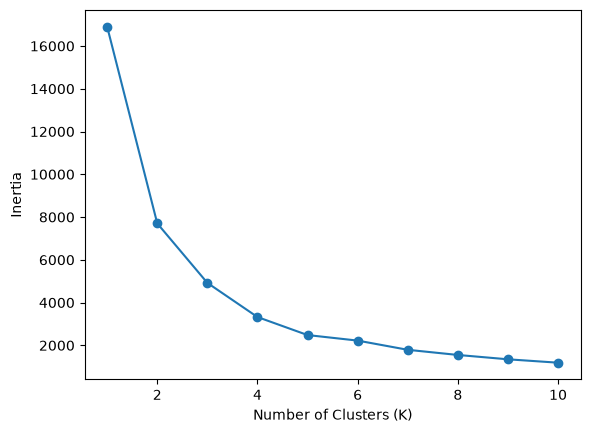

In [750]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia_values.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.show()

Visually here we can see that there are quite extreme changes between K = 1 up until K = 4. After that, the changes are not that big and the curve becomes, in a way, straighter. The elbow point here is either K = 3 or 4, since inertia drops are way too small after that.

---
Model Training: Silhouette Score
---

In [751]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = list(range(2, 11))

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)
    print(f'k={k}: silhouette score = {score:.4f}')

k=2: silhouette score = 0.4812
k=3: silhouette score = 0.4513
k=4: silhouette score = 0.4709
k=5: silhouette score = 0.4433
k=6: silhouette score = 0.4405
k=7: silhouette score = 0.4320
k=8: silhouette score = 0.4277
k=9: silhouette score = 0.4278
k=10: silhouette score = 0.4345


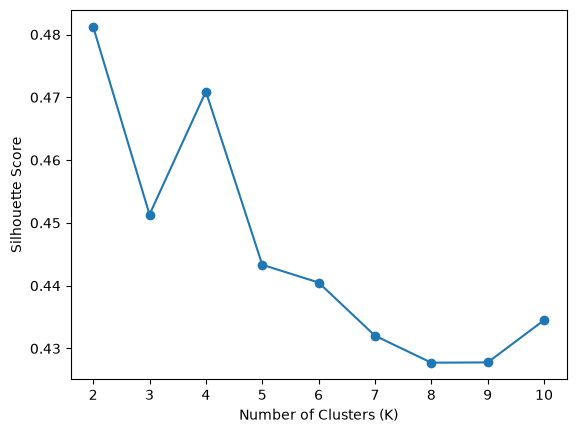

In [752]:
plt.plot(list(k_range_sil), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range_sil))
plt.show()

As a silhouette score's main aim is to find how well the clusters are separated, with a range of -1 to 1, the higher the score the tighter and more distinct the cluster is. Here, the highest value is K = 2, with a silhouette score of 0.4812. Although, K=4 also has quite a high score with 0.4709, creating a spike as K = 3 is significantly less than K = 2. 

---
Model Training: Choosing Final K
---

In [753]:
print('k2 - k3:', inertia_values[k_range.index(2)] - inertia_values[k_range.index(3)])
print('k3 - k4:', inertia_values[k_range.index(3)] - inertia_values[k_range.index(4)])
print('k4 - k5:', inertia_values[k_range.index(4)] - inertia_values[k_range.index(5)])
print('k5 - k6:', inertia_values[k_range.index(5)] - inertia_values[k_range.index(6)])
print('k6 - k7:', inertia_values[k_range.index(6)] - inertia_values[k_range.index(7)])

k2 - k3: 2781.312737225746
k3 - k4: 1596.9859844919142
k4 - k5: 843.1265793473258
k5 - k6: 258.9090196173206
k6 - k7: 430.7471767149036


In [754]:
print('k2 - k3:', silhouette_scores[k_range_sil.index(2)] - silhouette_scores[k_range_sil.index(3)])
print('k3 - k4:', silhouette_scores[k_range_sil.index(3)] - silhouette_scores[k_range_sil.index(4)])
print('k4 - k5:', silhouette_scores[k_range_sil.index(4)] - silhouette_scores[k_range_sil.index(5)])

k2 - k3: 0.029916785779534827
k3 - k4: -0.019595207376194412
k4 - k5: 0.027591686131563875


In [755]:
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_k4 = kmeans_k4.fit_predict(X_cluster)

unique_k4, counts_k4 = np.unique(labels_k4, return_counts=True)
print('k=4: cluster sizes =', 
      dict(zip(unique_k4, counts_k4)))

k=4: cluster sizes = {np.int32(0): np.int64(920), np.int32(1): np.int64(1368), np.int32(2): np.int64(1550), np.int32(3): np.int64(1796)}


Based off of the results from both the elbow point and the silhouette scores, K = 4 as the amount of clusters is the best choice. Not only does it still have quite a huge inertia drop, its silhouette score is quite similar to K = 2. This will allow for more than 2 groups and would offer more insight on different categories of customers, compared to K = 2. In addition, it was checked for balance and all of the cluster sizes are more or less quite similar and it does not just produce one giant cluster.

In [756]:
final_k = 4
final_kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
labels_cluster_train = final_kmeans.fit_predict(X_cluster)

print('Final k = 4.')

Final k = 4.


---
Model Assessment: Test Data Evaluation
---

In [757]:
labels_cluster_test = final_kmeans.predict(X_cluster_test)

unique_test, counts_test = np.unique(labels_cluster_test, return_counts=True)

print("Test data's cluster sizes:", dict(zip(unique_test, counts_test)))
print("Test data's silhouette score:", silhouette_score(X_cluster_test, labels_cluster_test))

Test data's cluster sizes: {np.int32(0): np.int64(242), np.int32(1): np.int64(337), np.int32(2): np.int64(355), np.int32(3): np.int64(475)}
Test data's silhouette score: 0.4766592285664372


Now we apply the K Means model to the test set. By using the predict function, each test point is assigned to one of the four clusters, depending on which center it is closest to. This silhouette score is quite similar to the one that was found for training data. The cluster sizes are quite close as well, which shows that this model overall can generalize the unseen customers well.

---
Data Visualization: PCA Clusters
---

In [758]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_cluster)

print("Ratio of variances:", pca.explained_variance_ratio_)
print("Variance, but two components:", pca.explained_variance_ratio_.sum())

Ratio of variances: [0.73002681 0.2504298 ]
Variance, but two components: 0.9804566050410998


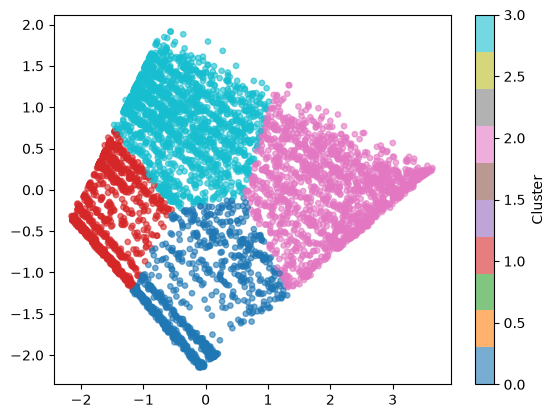

In [759]:
scatter = plt.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=labels_cluster_train, cmap='tab10', alpha=0.6, s=15
)

plt.colorbar(scatter, label='Cluster')
plt.show()

Three features were used for the clustering: tenure, MonthlyCharges, TotalCharges and PCA compressed them to two components to create the above graph. If you add the two variances, you get around 0.98, meaning that only 2% so very little amount of information was lost through this process. This means that the graph is representative of the actual clustering. 

On another observation, there are four clusters and they pretty much do not overlap. They are all quite visually distinct, which was proven earlier with the silhouette score.

---
Data Visualization: Separating Clusters
---

In [760]:
profile_df = train_df.copy()
profile_df['cluster'] = labels_cluster_train
profile_df[['tenure_unscaled', 'MonthlyCharges_unscaled', 'TotalCharges_unscaled']] = scaler.inverse_transform(
    profile_df[['tenure', 'MonthlyCharges', 'TotalCharges']]
)

In [761]:
cluster_summary = profile_df.groupby('cluster').agg(
    churned=('Churn', 'size'),
    churn_rate=('Churn', 'mean'),
    average_tenure=('tenure_unscaled', 'mean'),
    average_monthlycharges=('MonthlyCharges_unscaled', 'mean'),
    monthlycharges_std=('MonthlyCharges_unscaled', 'std'),
    average_totalcharges=('TotalCharges_unscaled', 'mean'),
)
print(cluster_summary)

         churned  churn_rate  average_tenure  average_monthlycharges  \
cluster                                                                
0            920    0.051087       53.472826               35.122228   
1           1368    0.241228       10.345760               31.752485   
2           1550    0.160000       59.436774               93.392161   
3           1796    0.484410       15.337416               80.906292   

         monthlycharges_std  average_totalcharges  
cluster                                            
0                 16.199612           1849.533152  
1                 13.344012            306.494920  
2                 14.180192           5545.143613  
3                 12.559066           1246.449582  


Before building a summary table that shows the averages among each of these values, we had to first unscale the values. This way instead of having standardized units, we would have actual months and dollars. 

Cluster 0:
This cluster has only a 5% of a churn rate, as they have had these services, on average, for 53 months (based on average tenure). Following this, they are charged only about 35 dollars a month.

Cluster 1:
This cluster has a bit higher percentage of churn rate with 24%. These are are quite the new customers, as their average tenure is 10 months and they pay around 32 dollars a month.

Cluster 2: 
This cluster has a churn rate of 16%, with the highest average tenure of 59 months. They also pay the most, monthly, with around 93 dollars.

Cluster 3: 
This is the cluster that has the highest churn rate of 48%, most likely due to the low average tenure of 15 (despite not being the lowest) and the second highest monthly charges of 81 dollars.

---
Data Visualization: Cluster Outliers - Churn
---

In [762]:
cluster_churn_rates = profile_df.groupby('cluster')['Churn'].mean().rename('cluster_churn_rate')
profile_df = profile_df.merge(cluster_churn_rates, on='cluster', how='left')

profile_df['unexpected_churn'] = (profile_df['Churn'] == 1) & (profile_df['cluster_churn_rate'] < 0.20)
#Are in a cluster where churn is rare, but still churned

profile_df['unexpected_stay'] = (profile_df['Churn'] == 0) & (profile_df['cluster_churn_rate'] > 0.40)
#are in a cluster where churn is common, but still stayed

In [763]:
print('Unexpected churners:', profile_df['unexpected_churn'].sum())
print('Unexpected stayers:', profile_df['unexpected_stay'].sum())

Unexpected churners: 295
Unexpected stayers: 926


As the main target throughout this entire project was Churn, I decided to use the clusters' churn patterns to distinguish these results.

I looked into people that leave despite being in a cluster that has a low churn rate (under 20%) as well as customers that stayed despite being in a cluster that has a high churn rate (above 40%). Overall, what this shows is that tenure and charges could be used as feature for prediction, they are not that reliable as they do not go into details about individual behaviours, unlike a supervised model.

---
Final Discussion
---

1. Overall Strengths and Limitations of the Proposed Solution

Both the supervised and unsupervised models showed that churn can indeed be predicted from the available features. For the tuned Logistic Regression, it produced an F1 score of 0.61 as well as a ROC-AUC of 0.84 for the churn category. Whilst the K Means with 4 clusters had a silhouette score of 0.471 and various churn rates. 

The main limitations were regarding the precision for the churn class, at 0.51 which show that nearly half of the customers that are predicted to be churned, actually will not. This could be quite costly, if a business decides to use this. 

Moving on, despite the tuned Logistic Regression being chosen as the last supervised model, it is important to mention what was found through KNN. It came back with an F1 score of 0.585 (lower than Logistic Regression's) and was also unable to show which feature actually helped make the predictions it had. 

Apart from that, K means only focused on the features tenure,MonthlyCharges and TotalCharges, as those were considered the main customer churn driving factor. However, to further expand on this, other features such as contract type etc. could be used. This could really help form the clusters better than the current ones.

As the last point, K means could also be tested with K = 2 or K = 3. In this process, I went with K = 4 due to it seemingly looking the most like the elbow point as well as having a high silhouette score. This, however, could have been tested with other K values that could have provided way more meaningful documentation.

2. What are the implication of the results for the business problem?

The question that I originally focused on whether or not churn was something that could be predicted through customer attributes as well as the possibility of there being various clients with different risk levels. Both the supervised and unsupervised models proved both of those questions. 

Logistic Regression shows that churn is something that can be learned through a customer's data and eventually predicted with average accuracy. This way a business can help customers that are at risk of leaving by flagging them first.

K Means also supports this, as it was discovered that there are many distinct customers with quite different churn rates. This shows that a business should always have multiple approaches for keeping the retention of their customers.

3. What are your data-driven recommendations for solving the initial business problem?

I would recommend using both of the models. You first start by using the tuned Logistic Regression to create a score for each of the current customers, judged according to who is most likely to churn. After that with the four clusters organized by K Means, the company can determine where exactly they should focus. By offering the customers that have a higher churn rate various retention approaches, the business is more likely to keep them and hence saving costs rather than aimlessly targeting individuals.

4. What are the most informative features of your model?

Starting with the Logistic Regression, by looking at its coefficients we can see that InternetService had a huge effect on churn. If someone did not have internet service, they have way less chance to churn. A few other features that lowered the churn risk were tenure, MonthlyCharges etc. Moving to what K Means discovered, it lines up perfectly. If a cluster had loger contracts, they had very low churn rate. Unfortunately, KNN has no coefficients or clusters it can identify, hence it is unable to determine which features were important or not.

5. Is your model explainable?

Both Logistic Regression and K Means are explainable. Whilst Logistic Regression focuses on showing which coefficients affect churn probability and by how much, K means has clusters that can group customers depending on their data. KNN is the only one that is not explainable, since the only thing it can tell is whether a customer resembles another customer that churned, but not really what caused it.

6. Will you deploy your model?

With a lot more work and polishing, it could be deployed. This dataset focuses on a set period of time and would need another dataset to be operational. This dataset would need to be updated from time to time, as stuff such as customer behaviour may change over time. Otherwise, the model would not give very accurate churn predictions as the data it currently uses is quite outdated. Clustering would also not be that effective with this old data, since the new customers may have completely different features compared to the ones used for this project.

---
Link
---

Dataset used:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn